# Website Data

In [2]:
import matplotlib.pyplot as plt
import matplotx
import numpy as np
import pandas as pd
import plot_lib as pl
import stats_lib as sl

ModuleNotFoundError: No module named 'matplotlib'

In [ ]:
labels = ['times', 'clicks']
web_data = pd.read_csv('website_stats.txt', sep=r'\s+')

df_a = web_data.loc[:, 'web_a_times':'web_a_clicks']
df_a.columns = labels

df_b = web_data.loc[:, 'web_b_times':'web_b_clicks']
df_b.columns = labels

df = {'a': df_a, 'b': df_b}

In [ ]:
def get_clicks_per_min(times, clicks):
    clicks_per_minute = []
    for time, click in zip(times, clicks):
        clicks_per_minute.append(click/time)
    return clicks_per_minute
df_stats = {
    'a': {
        'times': sl.get_basic_stats(df['a']['times']),
        'clicks': sl.get_basic_stats(df['a']['clicks']),
        'clicks_per_min': sl.get_basic_stats(get_clicks_per_min(df['a']['times'], df['a']['clicks']))
    },
    'b': {
        'times': sl.get_basic_stats(df['b']['times']),
        'clicks': sl.get_basic_stats(df['b']['clicks']),
        'clicks_per_min': sl.get_basic_stats(get_clicks_per_min(df['b']['times'], df['b']['clicks']))
    }
}

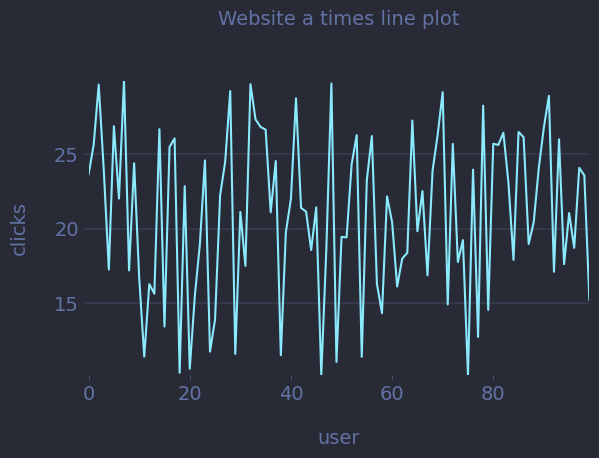

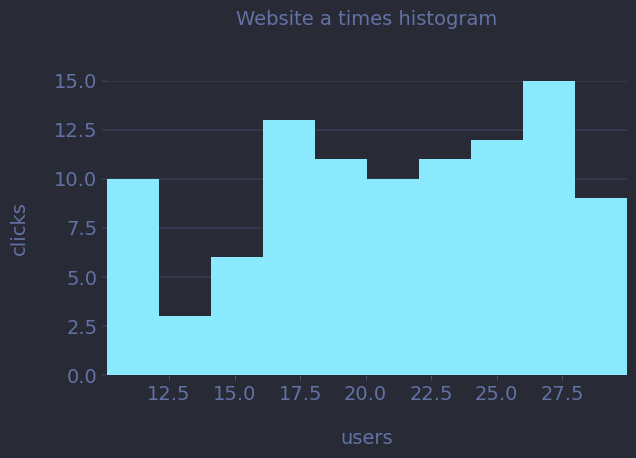

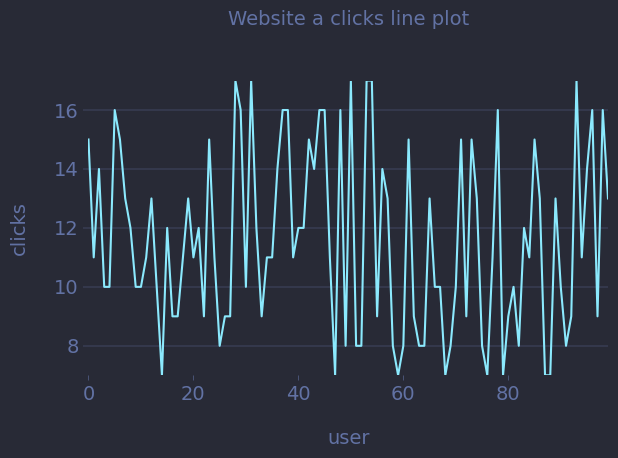

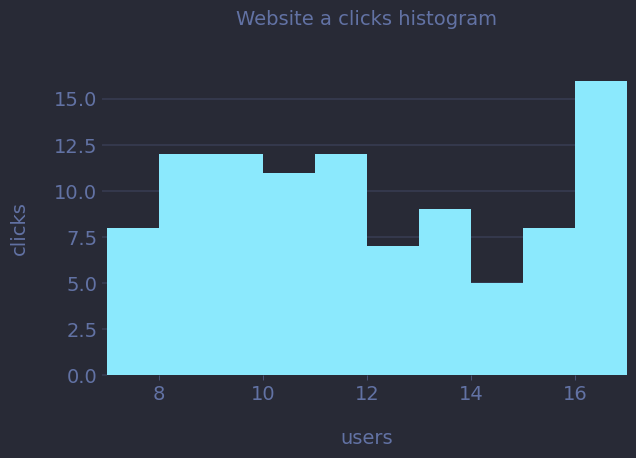

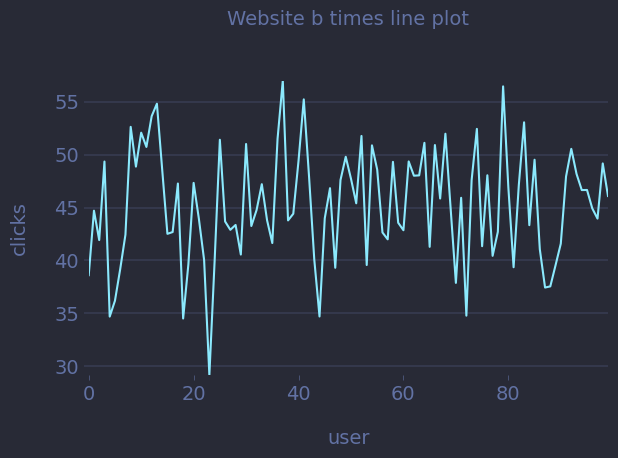

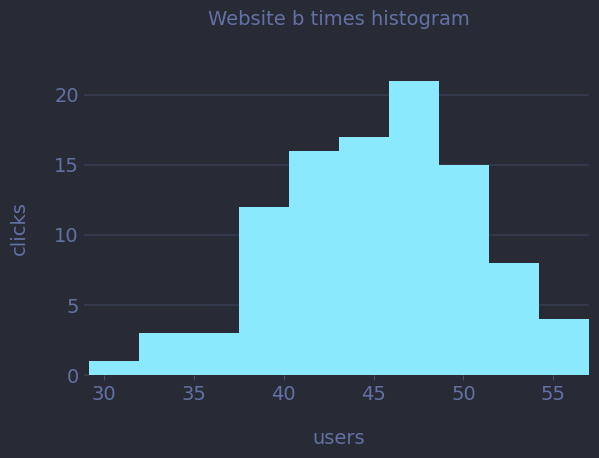

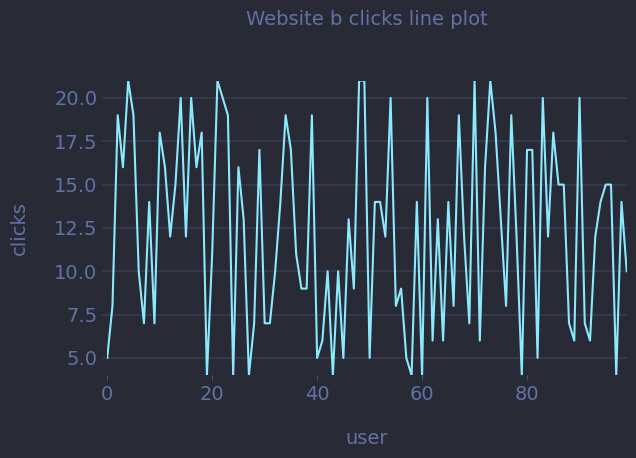

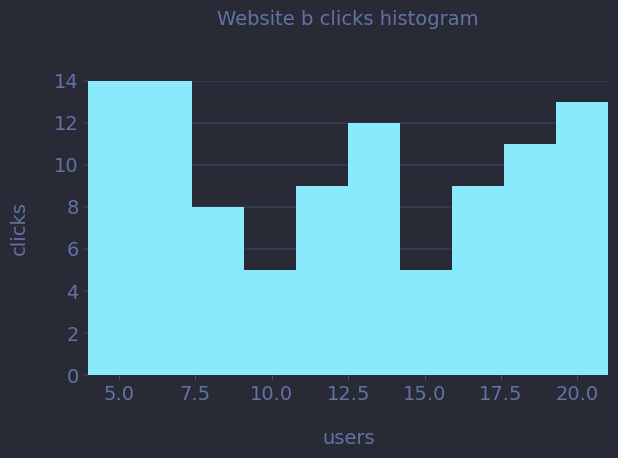

In [ ]:
# all line/hist plots

for web_key, web in df.items():
    for data_key, data in web.items():
        title_prefix = f'Website {web_key} {data_key}'
        plots = [pl.LinePlot(data, title = title_prefix + ' line plot', x_title='user', y_title='clicks'), pl.HistPlot(data, title = title_prefix + ' histogram', x_title='users', y_title='clicks')]
        for plot in plots:
            pl.SubPlot([plot]).plot()
            

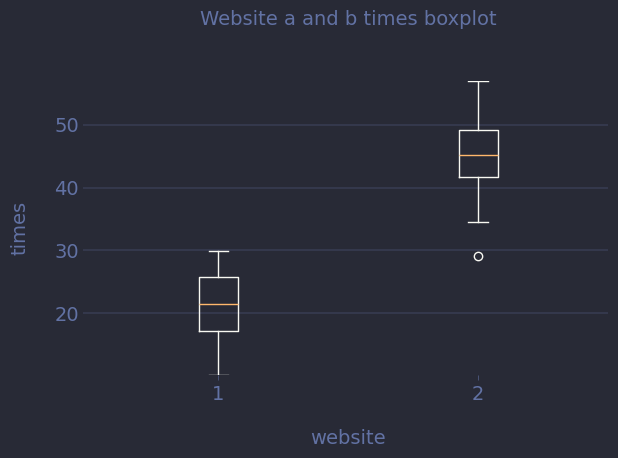

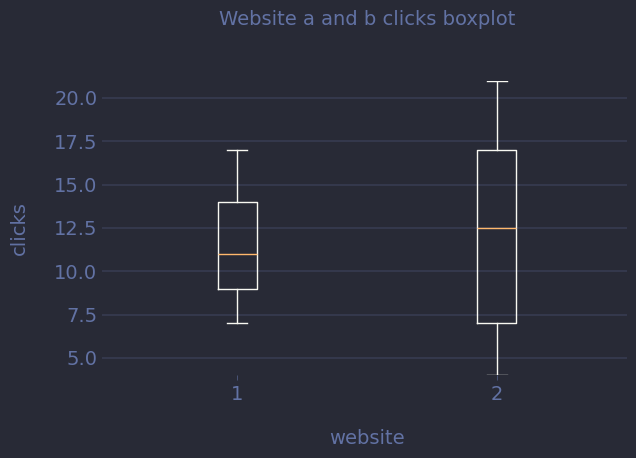

In [ ]:
# box plots

for data_key in df['a'].keys():
    data = [df['a'][data_key], df['b'][data_key]]
    title = f'Website a and b {data_key} boxplot'
    plot = pl.BoxPlot(data, title=title, x_title='website', y_title=data_key)
    pl.SubPlot([plot]).plot()
    

In [ ]:
from pprint import pprint

def to_builtin(obj):
    if isinstance(obj, dict):
        return {k: to_builtin(v) for k, v in obj.items()}
    elif isinstance(obj, np.generic):  # np.float64, np.int64, etc.
        return obj.item()
    else:
        return obj

cleaned = to_builtin(df_stats)

def pretty_dict(d, indent=0):
    for key, value in d.items():
        if isinstance(value, dict):
            print(" " * indent + f"{key}:")
            pretty_dict(value, indent + 4)
        else:
            formatted = f"{value:.3f}" if isinstance(value, float) else str(value)
            print(" " * indent + f"{key}: {formatted}")

pretty_dict(cleaned)

a:
    times:
        mean: 21.004
        median: 21.415
        var: 29.785
        std: 5.458
        min: 10.140
        max: 29.960
    clicks:
        mean: 11.550
        median: 11.000
        var: 9.467
        std: 3.077
        min: 7
        max: 17
    clicks_per_min:
        mean: 0.597
        median: 0.562
        var: 0.063
        std: 0.251
        min: 0.262
        max: 1.494
b:
    times:
        mean: 45.244
        median: 45.160
        var: 28.539
        std: 5.342
        min: 29.130
        max: 57.010
    clicks:
        mean: 12.360
        median: 12.500
        var: 30.130
        std: 5.489
        min: 4
        max: 21
    clicks_per_min:
        mean: 0.279
        median: 0.277
        var: 0.018
        std: 0.136
        min: 0.071
        max: 0.652
